# 00 - What is this data, actually?

**Read this before any other notebook.** Everything downstream - chunking, embedding, retrieval -
is downstream of what is actually in these rows.

By the end you will be able to answer, from evidence you generated yourself:

1. What fields exist, what types they are, and how often they are empty
2. Why `details` is the richest and messiest field, and what its long tail costs you
3. How much text each product actually carries, and whether chunking will matter
4. How one raw row becomes one retrievable document, and why that choice caps your accuracy

Nothing here is taken on trust. Every claim is computed from real rows in front of you.

> The experiment plan lives in `context/02-plan.md`; dataset licensing and alternatives live in
> `DATA_LICENSES.md`. This notebook is only about the data.

## 0. Setup

We stream the raw JSONL straight from Hugging Face rather than downloading the dataset. The
Automotive metadata file is **5.35 GB and about 2 million products**, so we read it line by line
over HTTP and stop as soon as we have 500 rows - a couple of seconds, a few megabytes.

> **Why not `datasets.load_dataset`?** This dataset ships a Python loading script, and
> `datasets` 4.x removed support for those (`RuntimeError: Dataset scripts are no longer
> supported`). The underlying file is plain JSONL, so streaming it directly is both simpler and
> faster. That is what `src/fitment_rag/data/amazon.py` does.

Everything is already installed via Poetry - just make sure this notebook is running on the
`fitment-rag` kernel.

In [1]:
import json, itertools
from collections import Counter

import pandas as pd

import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent / "src"))
from fitment_rag.config import DataConfig
from fitment_rag.data.amazon import stream_rows

pd.set_option("display.max_colwidth", 90)
pd.set_option("display.width", 200)

N = 500
data_cfg = DataConfig()
print(f"streaming from: {data_cfg.hf_file}")

rows = list(itertools.islice(stream_rows(data_cfg), N))
print(f"pulled {len(rows)} raw rows (file is 5.35 GB -- we read only the prefix)")

streaming from: raw/meta_categories/meta_Automotive.jsonl


pulled 500 raw rows (file is 5.35 GB -- we read only the prefix)


## 1. One raw row, completely unedited

This is what the dataset actually hands you. Read it before reading my description of it.

In [2]:
print(json.dumps(rows[0], indent=2, ensure_ascii=False)[:2500])

{
  "main_category": "Automotive",
  "title": "Caltric 3 Pack Oil Filter Compatible with Suzuki 1100 Gsx1100E Gsx1100S Gsx-1100 S Katana 1100 1981-1985",
  "average_rating": 5.0,
  "rating_number": 1,
  "features": [],
  "description": [
    "Compatible with Suzuki modelsGSX1100E 1100 1983-1985GSX1100S Katana 1100 1981-1984"
  ],
  "price": 13.0,
  "images": [
    {
      "thumb": "https://m.media-amazon.com/images/I/51HL5kIokeL._AC_US40_.jpg",
      "large": "https://m.media-amazon.com/images/I/51HL5kIokeL._AC_.jpg",
      "variant": "MAIN",
      "hi_res": "https://m.media-amazon.com/images/I/719FB7OJyTL._AC_SL1000_.jpg"
    }
  ],
  "videos": [],
  "store": "Caltric",
  "categories": [
    "Automotive",
    "Motorcycle & Powersports",
    "Parts",
    "Filters",
    "Oil Filters"
  ],
  "details": {
    "Manufacturer": "Caltric",
    "Brand": "Caltric",
    "Manufacturer Part Number": "FL121+FL121+FL121/17",
    "Date First Available": "March 26, 2014"
  },
  "parent_asin": "B00J9I1

## 2. The schema, field by field

Now the systematic version. `fill_rate` is the fraction of the 500 sampled rows where the field
has a usable value - **this is the number that decides which experiments are viable.** A field
that is 30% empty cannot carry a benchmark.

In [3]:
def is_filled(v):
    if v is None:
        return False
    if isinstance(v, str):
        return v.strip() not in ("", "None", "null", "nan")
    if isinstance(v, (list, dict)):
        return len(v) > 0
    return True

fields = []
for key in rows[0].keys():
    vals = [r.get(key) for r in rows]
    filled = [v for v in vals if is_filled(v)]
    example = next((v for v in filled), None)
    example = json.dumps(example, ensure_ascii=False) if isinstance(example, (list, dict)) else str(example)
    fields.append({
        "field": key,
        "type": type(vals[0]).__name__,
        "fill_rate": round(len(filled) / len(vals), 3),
        "example": (example or "")[:70],
    })

schema = pd.DataFrame(fields).sort_values("fill_rate", ascending=False)
display(schema)

,field,type,fill_rate,example
1,title,str,1.000,Caltric 3 Pack Oil Filter Compatible with Suzuki 1100 Gsx1100E Gsx1100
2,average_rating,float,1.000,5.0
3,rating_number,int,1.000,1
12,parent_asin,str,1.000,B00J9I1BD4
11,details,dict,1.000,"{""Manufacturer"": ""Caltric"", ""Brand"": ""Caltric"", ""Manufacturer Part Num"
7,images,list,1.000,"[{""thumb"": ""https://m.media-amazon.com/images/I/51HL5kIokeL._AC_US40_."
0,main_category,str,0.998,Automotive
9,store,str,0.988,Caltric
10,categories,list,0.958,"[""Automotive"", ""Motorcycle & Powersports"", ""Parts"", ""Filters"", ""Oil Fi"
4,features,list,0.866,"[""Note: Fit for aftermarket wheels only, not fit for factory OEM wheel"


### What each field means

| field | what it is | matters because |
|---|---|---|
| `parent_asin` | Amazon's product id | **our `doc_id`** - the unit retrieval is scored against |
| `title` | product name | the single most identifying text; most queries key off it |
| `main_category` | top-level category | coarse; nearly always "Automotive" here, so low signal |
| `categories` | full category path | the closest thing to a taxonomy in this data |
| `features` | bullet points | short factual claims - often where a real answer lives |
| `description` | long marketing prose | verbose, repetitive, sometimes the only spec source |
| `details` | **free-form key/value dict** | brand, dimensions, part numbers - the richest and messiest field |
| `price` | string, often missing | a clean factual target for eval questions when present |
| `average_rating` / `rating_number` | review aggregates | factual, always present - reliable eval targets |
| `store` | brand or seller | the practical "brand" field |
| `images` / `videos` | media URLs | unused - this is a text benchmark |
| `bought_together` | co-purchase ids | unused here; interesting for recommendation work |

Check the `fill_rate` column against this table. **Where they disagree, believe the data.**

## 3. The `details` field - the interesting mess

`details` is a free-form dictionary, so different products carry entirely different keys. That
makes it the richest source of factual attributes *and* the reason this data is harder than it
looks: you cannot rely on any particular key existing.

In [4]:
detail_keys = Counter()
for r in rows:
    d = r.get("details")
    if isinstance(d, str):
        try:
            d = json.loads(d)
        except json.JSONDecodeError:
            d = {}
    if isinstance(d, dict):
        detail_keys.update(d.keys())

print(f"{len(detail_keys)} distinct keys across {len(rows)} products\n")
pd.DataFrame(detail_keys.most_common(25), columns=["details key", "n products"])

246 distinct keys across 500 products



,details key,n products
0,Date First Available,494
1,Brand,463
2,Manufacturer,453
3,Manufacturer Part Number,399
4,Item Weight,390
5,Best Sellers Rank,351
6,Item model number,246
7,Product Dimensions,215
8,Material,181
9,Is Discontinued By Manufacturer,181


**Read the long tail, not just the top.** A few keys appear on most products (Brand,
Manufacturer, Item Weight) while hundreds appear a handful of times. That distribution is the
core retrieval challenge: the answer to "what is the thread pitch" lives in a key that exists on
2% of products.

This is also why the eval set is built from the *always-present* fields (store, price, rating,
category) rather than from `details`. Ground truth has to be reliable before it can be a
benchmark - and that constraint is worth stating in your writeup rather than hiding.

,title,features,description,total
count,500.0,500.0,500.0,500.0
mean,104.0,456.0,388.0,947.0
std,48.0,434.0,585.0,791.0
min,4.0,0.0,0.0,30.0
25%,65.0,128.0,0.0,328.0
50%,101.0,322.0,162.0,810.0
75%,137.0,709.0,585.0,1317.0
max,211.0,2168.0,4658.0,4860.0


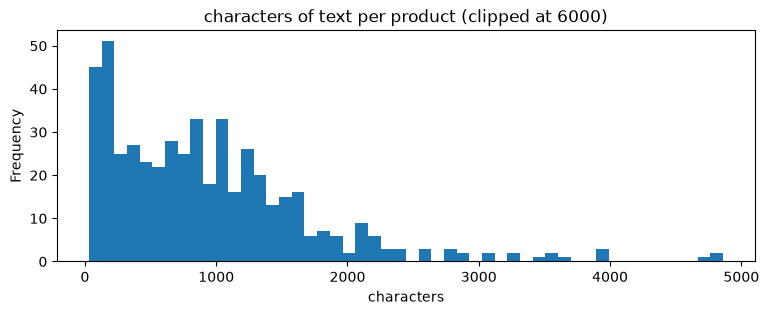

In [5]:
# How much text is there per product? This decides whether chunking matters at all.
lens = pd.DataFrame({
    "title":       [len(str(r.get("title") or "")) for r in rows],
    "features":    [len(" ".join(r.get("features") or [])) for r in rows],
    "description": [len(" ".join(r.get("description") or [])) for r in rows],
})
lens["total"] = lens.sum(axis=1)
display(lens.describe().round(0))

ax = lens["total"].clip(upper=6000).plot.hist(bins=50, figsize=(9, 3),
                                              title="characters of text per product (clipped at 6000)")
ax.set_xlabel("characters");

**Look at the median against the 512-character chunk size.** If most products are under
512 characters, then "chunking" is doing almost nothing for most of the corpus and Phase 1b will
show a flat result. That is a real finding, not a wasted experiment - but you want to *predict* it
here rather than be surprised by it later.

## 4. From raw row to retrievable document

A vector index stores text, not dicts. So every row must be flattened into one string - and
**that flattening is a design decision that sets your accuracy ceiling.** If a field does not make
it into the text, no retriever can ever find it, no matter how good the embedding model is.

Here is what `src/fitment_rag/data/amazon.py::_doc_text` does, and the reasoning:

| field | in the document? | why |
|---|---|---|
| title | yes, first | most identifying signal, and embedders weight early tokens |
| store | yes, labelled `Brand/Store` | brand is a common query intent |
| categories | yes, as a path | gives coarse semantic grounding |
| price | yes when present | a clean eval target |
| features | yes, `\|`-joined | short factual claims |
| description | yes | verbose, but sometimes the only spec source |
| details | yes, flattened `k: v` | the attribute goldmine |
| images/videos | **no** | not a multimodal benchmark |
| bought_together | **no** | recommendation signal, not retrieval content |
| average_rating | kept as metadata, not text | numeric; better as a filter than as prose |

Field labels (`Title:`, `Brand/Store:`) are deliberate. They give the embedder lexical anchors,
so a query containing the word "brand" has something to match.

In [6]:
from fitment_rag.data.amazon import _doc_text

r = rows[0]
print("=== RAW (keys only) ===")
print({k: (f"<{type(v).__name__}>" if isinstance(v, (list, dict)) else str(v)[:40])
       for k, v in r.items()})

print("\n=== FLATTENED DOCUMENT ===")
print(_doc_text(r))

=== RAW (keys only) ===
{'main_category': 'Automotive', 'title': 'Caltric 3 Pack Oil Filter Compatible wit', 'average_rating': '5.0', 'rating_number': '1', 'features': '<list>', 'description': '<list>', 'price': '13.0', 'images': '<list>', 'videos': '<list>', 'store': 'Caltric', 'categories': '<list>', 'details': '<dict>', 'parent_asin': 'B00J9I1BD4', 'bought_together': 'None'}

=== FLATTENED DOCUMENT ===
Title: Caltric 3 Pack Oil Filter Compatible with Suzuki 1100 Gsx1100E Gsx1100S Gsx-1100 S Katana 1100 1981-1985
Brand/Store: Caltric
Categories: Automotive > Motorcycle & Powersports > Parts > Filters > Oil Filters
Price: 13.0
Description: Compatible with Suzuki modelsGSX1100E 1100 1983-1985GSX1100S Katana 1100 1981-1984
Details: Manufacturer: Caltric | Brand: Caltric | Manufacturer Part Number: FL121+FL121+FL121/17 | Date First Available: March 26, 2014


In [7]:
# Documents shorter than 120 chars are dropped -- they poison retrieval evals.
# How many does that filter remove, and what do they look like?
docs = [(r.get("parent_asin"), _doc_text(r)) for r in rows]
short = [(a, t) for a, t in docs if len(t) < 120]

print(f"{len(short)}/{len(docs)} rows dropped as too short ({len(short)/len(docs):.1%})\n")
for a, t in short[:3]:
    print(f"[{a}] {len(t)} chars: {t!r}\n")

kept = [len(t) for _, t in docs if len(t) >= 120]
print(f"kept {len(kept)} docs | median {int(pd.Series(kept).median())} chars "
      f"| p90 {int(pd.Series(kept).quantile(0.9))} chars")

0/500 rows dropped as too short (0.0%)

kept 500 docs | median 1402 chars | p90 2565 chars
